# pysyrev — Full pipeline tutorial

This notebook walks through the complete pysyrev pipeline using a small pre-screened dataset of 58 articles on agent-based models (ABM).

Since the dataset is already screened, we skip the `bib` and `review` stages and start directly from the bibliographic network and topic-modelling stages.

**Stages covered:**
1. Dataset exploration
2. Bibliographic network (`bib-network`)
3. Topic modelling (`topic-model`)
4. Report generation (`topic-report`)
5. Equivalent YAML config

> **Note:** Topic modelling uses `all-MiniLM-L6-v2` (lightweight, CPU-friendly) instead of the production `specter2` model to keep the notebook fast.

## 0. Setup

In [1]:
import os
os.environ['TOKENIZERS_PARALLELISM'] = 'false'  # prevent fork-after-parallel-init deadlock warning

from pathlib import Path
import pandas as pd

# Paths
DATASET_PATH = Path("../tests/data/bib_dataset.csv")
OUTPUT_DIR   = Path("outputs")          # all artefacts written here
OUTPUT_DIR.mkdir(exist_ok=True)

print(f"Dataset : {DATASET_PATH.resolve()}")
print(f"Outputs : {OUTPUT_DIR.resolve()}")

Dataset : /home/benjaminpillot/PycharmProjects/pysyrev/tests/data/bib_dataset.csv
Outputs : /home/benjaminpillot/PycharmProjects/pysyrev/tutorials/outputs


## 1. Dataset exploration

In [2]:
df = pd.read_csv(DATASET_PATH)
print(f"{len(df)} articles — columns: {list(df.columns)}")
df[["title", "year", "journal", "cited_by"]].head(10)

58 articles — columns: ['id', 'author', 'affiliations', 'abstract', 'journal', 'title', 'author_keywords', 'doi', 'language', 'document_type', 'references', 'year', 'cited_by', 'reference_ids', 'unresolved_references', 'shared_unresolved_references']


,title,year,journal,cited_by
0,"Stories, simulations and narratives: Collabora...",2025.0,AGRICULTURAL SYSTEMS,4
1,Analyzing the Industry Structure and Dynamics ...,2023.0,ECONOMIC AND SOCIAL CHANGES-FACTS TRENDS FORECAST,6
2,On the applicability of various levels of deta...,2023.0,BUILDING SIMULATION,9
3,Allocating synthetic population to a finer spa...,2023.0,ENVIRONMENT AND PLANNING B-URBAN ANALYTICS AND...,3
4,The importance of exploration: model predictio...,2026.0,THEORETICAL ECOLOGY,0
5,Complex adaptive systems-based framework for m...,2024.0,JOURNAL OF CLIMATE CHANGE AND HEALTH,13
6,"Logistics for Building Circular, Biobased, and...",2025.0,JOURNAL OF CIRCULAR ECONOMY,0
7,Multi-Agent Reinforcement Learning Optimizatio...,2024.0,ENERGIES,7
8,The circular economy mitigates the material re...,2023.0,JOURNAL OF CLEANER PRODUCTION,23
9,Assessment methodology for dynamic occupancy a...,2023.0,ENERGY AND BUILDINGS,22


<Axes: title={'center': 'Articles per year'}, xlabel='year'>

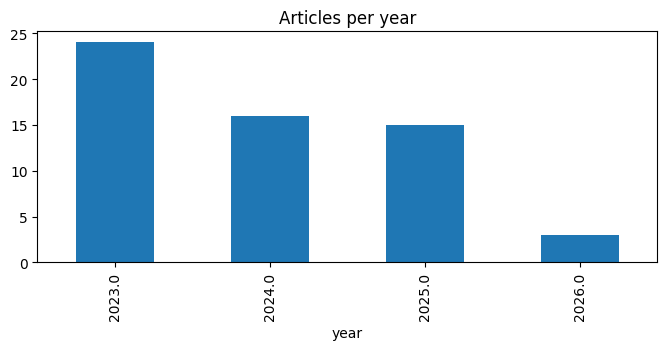

In [3]:
# Publication year distribution
df["year"].value_counts().sort_index().plot(
    kind="bar", title="Articles per year", figsize=(8, 3)
)

In [4]:
# Top journals
df["journal"].value_counts().head(10)

journal
AGRICULTURAL SYSTEMS                                           1
ECONOMIC AND SOCIAL CHANGES-FACTS TRENDS FORECAST              1
BUILDING SIMULATION                                            1
ENVIRONMENT AND PLANNING B-URBAN ANALYTICS AND CITY SCIENCE    1
THEORETICAL ECOLOGY                                            1
JOURNAL OF CLIMATE CHANGE AND HEALTH                           1
JOURNAL OF CIRCULAR ECONOMY                                    1
ENERGIES                                                       1
JOURNAL OF CLEANER PRODUCTION                                  1
ENERGY AND BUILDINGS                                           1
Name: count, dtype: int64

## 2. Bibliographic network

pysyrev builds two graphs from the reference lists:
- **Bibliographic coupling** — two articles are linked when they share at least one reference
- **Co-citation** — two references are linked when they are cited together by at least one article

In [5]:
from pysyrev.network import BibNetwork
from pysyrev.core.config import BibNetworkExportConfig

net = BibNetwork()
net.run(df)

print(f"Coupling  — {net.n_coupling_nodes:>4} nodes, {net.n_coupling_edges:>5} edges")
print(f"Co-citation — {net.n_cocitation_nodes:>4} nodes, {net.n_cocitation_edges:>5} edges")

Coupling  —   58 nodes,    29 edges
Co-citation — 2607 nodes, 92694 edges


In [6]:
# Export to GraphML (required by the report stage)
export_cfg = BibNetworkExportConfig(
    export_dir=str(OUTPUT_DIR / "bib_network"),
    run_name="tutorial_run",
)
net.save(export_cfg)

print(f"Coupling graph  → {export_cfg.coupling_graph}")
print(f"Co-citation graph → {export_cfg.cocitation_graph}")

Coupling graph  → outputs/bib_network/tutorial_run/coupling_network.graphml
Co-citation graph → outputs/bib_network/tutorial_run/cocitation_network.graphml


In [7]:
# Quick look at the coupling graph with networkx
import networkx as nx

G = nx.read_graphml(export_cfg.coupling_graph)
print(f"Top 5 most connected articles (by degree):")
top = sorted(G.degree(), key=lambda x: x[1], reverse=True)[:5]
for node_id, deg in top:
    title = G.nodes[node_id].get("title", node_id)[:80]
    print(f"  [{deg:>3} edges]  {title}")

Top 5 most connected articles (by degree):
  [  4 edges]  On the applicability of various levels of detail for occupant behavior   represe
  [  4 edges]  The importance of exploration: model predictions for ecosystem services   and fo
  [  4 edges]  The circular economy mitigates the material rebound due to investments   in rene
  [  4 edges]  Life history traits of the target pest and transmission routes of the   biocide 
  [  4 edges]  Enhancing the predictability of ecology in a changing world: A call for   an org


## 3. Topic modelling

pysyrev runs a grid search over UMAP + HDBSCAN configurations, ranks them by coherence score, and keeps the top N results.

Here we use deliberately small parameter ranges to keep the notebook fast (< 2 min on CPU).

In [8]:
from bertopic.vectorizers import ClassTfidfTransformer
from pysyrev.topic_model import (
    BertopicModel, HdbscanModel, TopicDistribution, TopicModel, UmapModel,
)

ctfidf = ClassTfidfTransformer(bm25_weighting=True, reduce_frequent_words=True)

umap_model = UmapModel(
    min_dist=0.0, metric="cosine", low_memory=False, random_state=42
)
hdbscan_model = HdbscanModel(
    metric="euclidean", cluster_selection_method="leaf", prediction_data=True
)
bertopic_model = BertopicModel(
    hdbscan_model=hdbscan_model,
    umap_model=umap_model,
    ctfidf_model=ctfidf,
    transformer_model="all-MiniLM-L6-v2",   # lightweight; swap for specter2 in production
    calculate_probabilities=True,
    n_gram_range="bigram",
    language="english",
)
topic_dist = TopicDistribution(window=4, stride=1, min_similarity=0.1, batch_size=100)

topic_model = TopicModel(
    doc_dataset=None,
    allow_abbrev=False,
    distance="euclidean",
    bertopic_model=bertopic_model,
    topic_distribution=topic_dist,
    nr_repr_docs=3,
    export_dir=str(OUTPUT_DIR / "topic_model"),
    n_neighbors=[5, 10],
    n_components=[3, 5],
    min_topic_size_range=[4, 8],
    min_sample_range=[2, 2],
    topic_size_step=2,
    min_sample_step=1,
    keep_n_results=5,
    ranking_scorer="u_mass",
    purity_scorer="c_v",
    run_name="tutorial_run",
    overwrite=True,   # safe to re-run: existing outputs are overwritten
)

print("Starting topic modelling…")
topic_model.run(df, show_progress=True)
print("Done.")

Starting topic modelling…


Filtering short documents: 100%|██████████| 8/8 [00:02<00:00,  3.52it/s]


[TopicModel] 58 documents in dataset → 58 survived preprocessing.


Batches:   0%|          | 0/2 [00:00<?, ?it/s]

Topic modeling in process...: 100%|██████████| 12/12 [00:07<00:00,  1.66it/s]

Done.


In [9]:
# Inspect the ranked results
run_dir = OUTPUT_DIR / "topic_model" / "tutorial_run"
metrics_csv = next((run_dir / "metrics").glob("*_best_results.csv"))
best = pd.read_csv(metrics_csv)
print(f"Top {len(best)} configurations:")
best[["nb_topics", "hdbscan", "umap", "c_v", "diversity"]].head()

Top 5 configurations:


,nb_topics,hdbscan,umap,c_v,diversity
0,5,6_2,10_5,0.381484,1.0
1,4,8_2,10_5,0.413379,1.0
2,4,6_2,5_3,0.432352,1.0
3,4,8_2,5_3,0.432352,1.0
4,6,4_2,10_5,0.337790,1.0


In [10]:
best.head()

,hdbscan,umap,nb_topics,entropy,u_mass,diversity,nb_outliers,distance,model,c_v,purity,distance_with_purity
0,6_2,10_5,5,1.493637,-0.348455,1.0,7,0.594370,"BERTopic(calculate_probabilities=True, ctfidf_...",0.381484,0.381484,0.830619
1,8_2,10_5,4,1.335461,-0.399500,1.0,6,1.028720,"BERTopic(calculate_probabilities=True, ctfidf_...",0.413379,0.413379,1.027041
2,6_2,5_3,4,1.328930,-0.407081,1.0,5,1.048785,"BERTopic(calculate_probabilities=True, ctfidf_...",0.432352,0.432352,1.000000
3,8_2,5_3,4,1.328930,-0.407081,1.0,5,1.048785,"BERTopic(calculate_probabilities=True, ctfidf_...",0.432352,0.432352,1.000000
4,4_2,10_5,6,1.598067,-0.478108,1.0,9,1.053626,"BERTopic(calculate_probabilities=True, ctfidf_...",0.337790,0.337790,1.414214


In [11]:
# Topics from the best configuration (model_index=0)
from pysyrev.core.report_data import find_best_results_csv, build_file_prefix

_, distance_name = find_best_results_csv(str(run_dir))
row = best.iloc[0]
prefix = build_file_prefix(row["hdbscan"], row["umap"], distance_name)
topic_info = pd.read_csv(run_dir / "topic_info" / f"{prefix}.csv")
topic_info[["Topic", "Count", "Name"]].head(15)

,Topic,Count,Name
0,-1,7,-1_tumor_resistance_tree_crosslinking
1,0,13,0_building_occupancy_modeling_behavior
2,1,13,1_energy_power_transition_market
3,2,11,2_transport_biomass_chain_logistic
4,3,8,3_food_russia_narrative_problem
5,4,6,4_health_sit_pest_rabies


## 4. Report generation

The report is a PDF that aggregates the topic-model results, bibliographic network stats, and temporal dynamics.

In [12]:
from pysyrev.core.config import (
    BibNetworkReportConfig,
    ReportConfig,
    ReportMetaConfig,
)
from pysyrev.topic_report import TopicReport

bib_cfg = BibNetworkReportConfig(
    coupling_graph=export_cfg.coupling_graph,
    cocitation_graph=export_cfg.cocitation_graph,
)

report_cfg = ReportConfig(
    meta=ReportMetaConfig(
        title="ABM Literature Review — Tutorial",
        author="pysyrev tutorial",
    )
)

report = TopicReport(
    run_dir=str(run_dir),
    report_config=report_cfg,
    model_index=0,
    export_to=str(OUTPUT_DIR / "report"),
    bib_network_config=bib_cfg,
)

pdf_path = report.generate_report()
print(f"Report written to: {pdf_path}")

Report written to: outputs/report/topic_report_2026-05-21_17-10-21.pdf


## 5. Equivalent YAML config

All of the above can be driven by a single YAML file and a one-liner CLI command.
Below is the minimal config that reproduces this tutorial (adapt paths as needed).

```yaml
# tutorial_config.yaml

bib_network:
  doc_dataset: tests/data/bib_dataset.csv
  coupling_network:
    use_resolved: true
    use_unresolved: true
    min_shared: 1
  cocitation_network:
    use_resolved: true
    use_unresolved: true
    min_cocitations: 1
  export:
    export_dir: tutorials/outputs/bib_network/
    run_name: tutorial_run

topic_model:
  doc_dataset: tests/data/bib_dataset.csv
  export:
    export_dir: tutorials/outputs/topic_model/
    run_name: tutorial_run
  distance: euclidean
  keep_n_results: 5
  hdbscan:
    min_topic_size_range: [4, 8]
    min_sample_range: [2, 2]
    topic_size_step: 2
    min_sample_step: 1
  umap:
    n_neighbors: [5, 10]
    n_components: [3, 5]
  bertopic:
    transformer_model: all-MiniLM-L6-v2
    n_gram_range: bigram

topic_report:
  model_index: 0
  export_to: tutorials/outputs/report/

report:
  meta:
    title: ABM Literature Review — Tutorial
    author: pysyrev tutorial
```

```bash
python -m pysyrev tutorials/tutorial_config.yaml
```